# Neural Networks: Multi-Layer Perceptrons

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/konstantin-schekotihin/dl_course/blob/master/AI-ML/04_NN.ipynb)


In [ ]:
# Setup & configuration (skip in presentation slides)
%matplotlib inline
import os
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import sys

from ipywidgets import interact
from sklearn.datasets import make_moons, load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as mt

# Ensure helpers.py is available (local file or direct GitHub fetch for standalone Colab)
try:
    import helpers as hp
except ImportError:
    import urllib.request
    _url = "https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/AI-ML/helpers.py"
    urllib.request.urlretrieve(_url, "helpers.py")
    import helpers as hp



## 1. Foundations of Connectionist Models

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/neuron.jpg" width="40%"/>
</center>
<p style="text-align:right">Copyright [AI:MA]</p>

+ Human neuron switching time ~$.001$ second
+ Number of neurons ~$10^{10}$
+ Connections per neuron ~$10^{4-5}$
+ Scene recognition time ~$.1$ second
+ 100 inference steps doesn't seem like enough
+ [$\rightarrow$] much parallel computation

### Properties of Artificial Neural Nets (ANNs)

- Many neuron-like threshold switching units
- Many weighted interconnections among units
- Highly parallel, distributed processing
- Emphasis on automatic feature selection 

### When to Consider Neural Networks
- Input is high-dimensional discrete or real-valued (e.g. raw sensor input)
- Output is discrete or real valued
- Output is a vector of values
- Possibly noisy data
- Form of the target function is unknown 
- Human-readability/explainability of a model/results is unimportant

## 2. The Perceptron & Single-Layer Models

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/ann-perceptron.jpg" width="50%"/>
</center>

- Input feature vector $\mathbf{x} = (1, x_1, \dots, x_D)^\mathrm{T} \in \mathbb{R}^{D+1}$ and weight vector $\mathbf{w} = (w_0, w_1, \dots, w_D)^\mathrm{T} \in \mathbb{R}^{D+1}$.
- Linear activation: $a = \mathbf{w}^\mathrm{T}\mathbf{x} = w_0 + \sum_{i=1}^{D} w_i x_i$.
- **Step Activation Function** (Heaviside step / hard limiter):

$$
y(\mathbf{x}) = 
\begin{cases}
    +1 & \text{if } \mathbf{w}^\mathrm{T}\mathbf{x} > 0 \\
    -1 & \text{if } \mathbf{w}^\mathrm{T}\mathbf{x} \le 0
\end{cases}
$$

<small>📖 *Source: [Rosenblatt, F. (1958). The perceptron: a probabilistic model for information storage and organization in the brain. Psychological Review, 65(6), 386–408](https://doi.org/10.1037/h0042519)*</small>


### Training a Perceptron

- Training dataset $\mathcal{D} = \{(\mathbf{x}_n, t_n)\}_{n=1}^N$ with design matrix $\mathbf{X} \in \mathbb{R}^{N \times (D+1)}$ and target vector $\mathbf{t} \in \{-1, +1\}^N$:

$$
\mathbf{X} = 
\begin{bmatrix}
    1 & x_{11} & \dots & x_{1D} \\
    1 & x_{21} & \dots & x_{2D} \\
    \vdots & \vdots & \ddots & \vdots \\
    1 & x_{N1} & \dots & x_{ND}
\end{bmatrix}, \quad
\mathbf{t} = 
\begin{bmatrix}
    t_1 \\
    t_2 \\
    \vdots \\
    t_N
\end{bmatrix}
$$


### The Perceptron Learning Algorithm

1. Initialize weight vector $\mathbf{w}^{(0)}$ to small random values or zeros.
2. For each training sample $(\mathbf{x}_n, t_n)$:
   - Compute prediction $\hat{t}_n = y(\mathbf{x}_n) = \mathrm{step}(\mathbf{w}^\mathrm{T}\mathbf{x}_n)$.
   - If correctly classified ($t_n = \hat{t}_n$), no update is made.
   - If misclassified ($t_n \neq \hat{t}_n$), update weights along the error direction with learning rate $\eta$:

$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} + \eta (t_n - \hat{t}_n) \mathbf{x}_n
$$

- **Perceptron Convergence Theorem**: If training data are linearly separable, the algorithm is guaranteed to converge in a finite number of steps.


In [2]:
class Perceptron:
    def __init__(self, h=0.01, epoch=1000, eps=0.0001):
        self.h = h
        self.epoch = epoch
        self.eps = eps

    def hardlim(self, x):
        out = torch.sign(x)
        out[out == 0] = -1
        return out

    def _predict(self, X):
        return self.hardlim(torch.matmul(X, self.w)).flatten()

    def _fit(self, X, labels):
        for i in range(self.epoch):
            y_hat = self._predict(X)
            err = torch.subtract(labels, y_hat)
            if torch.norm(err) < self.eps:
                break
            dw = torch.matmul(err, X).reshape(-1, 1)
            self.w += self.h * dw
        print(f"Epoch {i}: y_hat={y_hat}, err={err}, w={self.w.T}")

    def fit(self, data, labels):
        X = torch.cat((torch.ones((data.size()[0], 1)), data), 1)
        self.w = torch.randn((X.size()[1], 1)) / math.sqrt(X.size()[0])
        self._fit(X, labels)

    def predict(self, X):
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X).float()
        if X.size()[1] < self.w.size()[0]:
            X = torch.cat((torch.ones((X.size()[0], 1)), X), 1)
        return self._predict(X)


Epoch 17: y_hat=tensor([-1.,  1., -1., -1.]), err=tensor([0., 0., 0., 0.]), w=tensor([[-0.1607,  0.1377,  0.0687]])


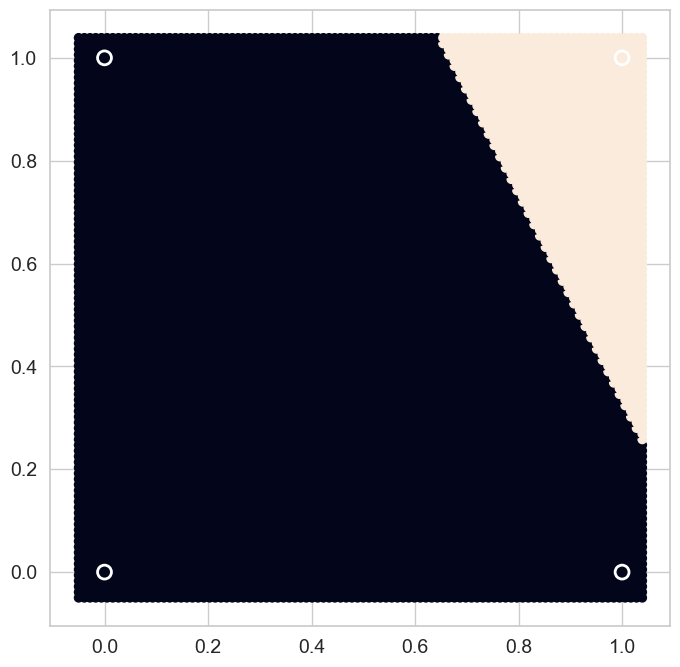

In [3]:
data = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
t = torch.tensor([-1., 1., -1., -1.])

p = Perceptron(epoch=100)
p.fit(data, t)

hp.plot_binary(p.predict, data, t)

### Decision Surface of a Perceptron

- Convergence is guaranteed if 
  - the training data is linearly separable, and
  - $\eta$ is sufficiently small, e.g., $\eta=0.1$
+ Decision surface of a two input ($x_1$ and $x_2$) perceptron: linearly (AND, OR, NAND) and non-linearly (XOR, EQ) separable
+ Perceptrons can represent linearly separable functions AND, OR, NAND, and NOR
+ Any Boolean function can be represented as a network of perceptrons

### Binary Classification & Linear Separability

In [ ]:
def rescale(X, min_val=-1, max_val=1):
    """Rescale tensor or array into [min_val, max_val]."""
    X_std = (X - X.min()) / (X.max() - X.min())
    return X_std * (max_val - min_val) + min_val

def get_logic_data(fn="and"):
    X = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
    logic_fns = {
        "and": lambda X: torch.logical_and(X[:, 0], X[:, 1]).float(),
        "or":  lambda X: torch.logical_or(X[:, 0], X[:, 1]).float(),
        "xor": lambda X: torch.logical_xor(X[:, 0], X[:, 1]).float(),
    }
    raw_y = logic_fns[fn](X)
    y = rescale(raw_y, min_val=-1, max_val=1)
    return X, y

def plot_perceptron_logic(fn="and"):
    X, y = get_logic_data(fn)
    clf = Perceptron()
    clf.fit(X, y)
    hp.plot_binary(clf.predict, X, y)


In [ ]:
interact(plot_perceptron_logic, fn=["and", "or", "xor"]);


### ADALINE: The Adaptive Linear Neuron

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/ann-adaline.jpg" width="60%"/>
</center>

- ADAptive Linear Neuron (Adaline) was published only few years after Rosenblatt's perceptron
- Can be considered as improvement of the first one, because it allows a learner to determine "how much" it was right or wrong
- Known also as *delta* or *Widrow-Hoff rule* (after its inventors)

### Mathematical Formulation & Error Objective

- Unlike the Perceptron, **ADALINE** updates weights using the continuous linear activation $a_n = \mathbf{w}^\mathrm{T}\mathbf{x}_n$ prior to thresholding:

$$
a_n = \mathbf{w}^\mathrm{T}\mathbf{x}_n = w_0 + \sum_{i=1}^{D} w_i x_{ni}
$$

- **Sum-of-Squares Error Objective** $E(\mathbf{w})$:

$$
E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^{N} (t_n - a_n)^2 = \frac{1}{2} \|\mathbf{t} - \mathbf{X}\mathbf{w}\|^2
$$

- The error surface $E(\mathbf{w})$ is a smooth quadratic bowl with a unique global minimum, optimized via **gradient descent**.


### Gradient Descent & The Delta Rule

- Weights are adjusted in the opposite direction of the gradient $\nabla E(\mathbf{w})$:

$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} - \eta \nabla E(\mathbf{w})
$$

- Computing the gradient with respect to weight parameter $w_j$:

$$
\frac{\partial E}{\partial w_j} = -\sum_{n=1}^{N} (t_n - a_n) x_{nj}
$$

- Leading to the **Delta Rule** (Widrow-Hoff rule):

$$
\Delta w_j = \eta \sum_{n=1}^{N} (t_n - a_n) x_{nj}
$$


### Gradient Derivation for Linear Units

- For the full parameter vector $\mathbf{w} = (w_0, w_1, \dots, w_D)^\mathrm{T}$:

$$
\nabla E(\mathbf{w}) = \left(\frac{\partial E}{\partial w_0}, \frac{\partial E}{\partial w_1}, \dots, \frac{\partial E}{\partial w_D}\right)^\mathrm{T}
$$

- Applying the chain rule to the squared error $E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^{N} (t_n - \mathbf{w}^\mathrm{T}\mathbf{x}_n)^2$:

$$
\begin{aligned}
\frac{\partial E}{\partial w_i} &= \frac{1}{2} \sum_{n=1}^{N} 2(t_n - \mathbf{w}^\mathrm{T}\mathbf{x}_n) \left(-\frac{\partial (\mathbf{w}^\mathrm{T}\mathbf{x}_n)}{\partial w_i}\right) \\
&= -\sum_{n=1}^{N} (t_n - a_n) x_{ni}
\end{aligned}
$$


### Matrix Formulation of the Delta Rule

+ Training rule for ADALINE in matrix form: 


$$ \nabla_w E[\mathbf{w}] = \nabla_w \frac{1}{2n} (\mathbf{t} - \mathbf{X}\mathbf{w})^\mathrm{T}(\mathbf{t} - \mathbf{X}\mathbf{w}) = \frac{1}{2n}(2\mathbf{X}^\mathrm{T}\mathbf{X}\mathbf{w} - 2\mathbf{X}^\mathrm{T}\mathbf{t})=\frac{1}{n}(\mathbf{X}^\mathrm{T}\mathbf{X}\mathbf{w} - \mathbf{X}^\mathrm{T}\mathbf{t})$$

### Batch vs. Stochastic Gradient Descent

- **Batch Gradient Descent**:
  - Evaluates error over the entire dataset $\mathcal{D}$ before each update:

$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} + \eta \sum_{n=1}^{N} (t_n - a_n) \mathbf{x}_n
$$

- **Stochastic Gradient Descent (SGD)**:
  - Updates weights sequentially after evaluating each single sample $n$:

$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} + \eta (t_n - a_n) \mathbf{x}_n
$$

- Faster, avoids local minima in complex surfaces, and enables online streaming updates.


> 📝 **Note:** *Stochastic Gradient Descent* can approximate *Batch Gradient Descent* arbitrarily closely if $\eta$ is made sufficiently small.


In [5]:
class AdaLine(Perceptron):
    def __init__(self, h=0.01, epoch=1000, eps=0.0001):
        super().__init__(h=h, epoch=epoch, eps=eps)

    def _fit(self, X, labels):
        m = 0
        n=X.size()[0]
        for i in range(self.epoch):
            # compute the gradient
            grad = -(1/n)*torch.subtract(torch.linalg.multi_dot([X.T, X, self.w]), 
                                         torch.matmul(X.T, labels).reshape(-1, 1))
            # termination criterion
            if m > 0 and (m - torch.norm(grad)) < self.eps: break
            m = torch.norm(grad)
            self.w += self.h*grad

        print("Epoch {}: grad={}, w={}".format(i, grad.T, self.w.T))

In [ ]:
def plot_adaline_logic(fn="and"):
    X, y = get_logic_data(fn)
    clf = AdaLine()
    clf.fit(X, y)
    hp.plot_binary(clf.predict, X, y)


In [ ]:
interact(plot_adaline_logic, fn=["and", "or", "xor"]);


### Summary of Single-Layer Units

- Perceptron is the first classification approach based on connectivists ideas
- Adaline is more general and can also be used to train thresholded perceptron units
- Linear unit training rule uses gradient descent
    - Guaranteed to converge to hypothesis with minimum squared error
    - Given sufficiently small learning rate $\eta$
    - Even when training data contains noise
    - Even when training data not separable by $H$

## 3. Smooth Activations & The Sigmoid Unit

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/ann-sigmoid.jpg" width="50%"/>
</center>

### The Smooth Sigmoid Unit

- Replacing step functions with the smooth, differentiable **sigmoid activation**:

$$
\sigma(a) = \frac{1}{1 + e^{-a}}
$$

- Convenient derivative property:

$$
\frac{\mathrm{d} \sigma}{\mathrm{d} a} = \sigma(a) (1 - \sigma(a))
$$

- Enables end-to-end differentiability across multi-layer networks!


> ⚠️ **Limitation:** Manually deriving analytical parameter update equations for complex multi-layer architectures is mathematically tedious and error-prone.


## 4. Computational Graphs & Backpropagation

- Backpropagation applies the calculus **chain rule** to propagate error gradients backwards from output layers to hidden layers.
- For composite function $f(q(x))$:

$$
\frac{\partial f}{\partial x} = \frac{\partial f}{\partial q} \frac{\partial q}{\partial x}
$$

- In multi-layer networks, intermediate gradients $\delta_j = \frac{\partial E}{\partial a_j}$ quantify the sensitivity of total error to hidden unit activations.

<small>📖 *Source: [Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. Nature, 323(6088), 533–536](https://doi.org/10.1038/323533a0)*</small>


### Computational Graphs for Automated Differentiation

- Exact analytical differentiation becomes unwieldy for deep, complex architectures.
- Computational graphs represent functions as directed acyclic graphs of elementary operations.
- Consider a sigmoid unit with two inputs trained on binary targets under squared error:

$$
E(\mathbf{w}) = \frac{1}{2} (t - \hat{y})^2, \quad \hat{y} = \sigma(a), \quad a = w_0 + w_1 x_1 + w_2 x_2
$$


### Computational Graph: Error Function & Gradient

- The loss function to optimize for sample $(\mathbf{x}, t)$ is:

$$
E(\mathbf{w}) = \frac{1}{2} \left(t - \frac{1}{1 + e^{-(w_0 + w_1 x_1 + w_2 x_2)}}\right)^2
$$

- Taking derivatives with respect to each parameter yields the gradient vector:

$$
\nabla E(\mathbf{w}) = \left(\frac{\partial E}{\partial w_0}, \frac{\partial E}{\partial w_1}, \frac{\partial E}{\partial w_2}\right)^\mathrm{T}
$$

- Gradient descent updates parameter vector $\mathbf{w}$ iteratively using these partial derivatives.


### Computational Graph: Forward & Backward Passes


<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/ann-sigmoid-small.svg" width="50%"/>
</center>

> 💡 **Key Takeaway:** The chain rule of calculus and computational graphs enable fully automated gradient calculation (backpropagation) across arbitrarily deep architectures.


### Detailed Forward Pass

<br/>
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/ann-sigmoid-comp.svg" width="50%"/>
</center>

### Detailed Backward Pass (Backpropagation)

- Consider an example in which 
   - we provide the first observation $\mathbf{x}=[1,3,-2]$ with the target classification label $t=0$
   - to the network with the weights $w_0=-1,w_1=2,$ and $w_2=2$ 
   
   
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/ann-sigmoid-ex.svg" width="60%"/>
</center>

### Numerical SGD Step on Computational Graph

- With stochastic gradient descent (SGD), the update occurs after evaluating each sample:
  - Learning rate $\eta = 0.1$
  - Sample gradient $\nabla E(\mathbf{w}) = (0.1437, 0.4312, -0.2875)^\mathrm{T}$
  - Parameter update:

$$
\mathbf{w}^{(\tau+1)} = \begin{bmatrix} -1 \\ 2 \\ 2 \end{bmatrix} - 0.1 \begin{bmatrix} 0.1437 \\ 0.4312 \\ -0.2875 \end{bmatrix} = \begin{bmatrix} -1.014 \\ 1.9569 \\ 3.0287 \end{bmatrix}
$$

- The optimization proceeds sequentially to the next observation.


## 5. Multi-Layer Perceptrons (MLP)

Overcoming linear separability limits by stacking hidden representation layers.


### Architecture: Hidden Layers & Representations

- **Forward Propagation Equations**:
  - Hidden layer activations ($j = 1, \dots, M$):

$$
a_j = \sum_{i=1}^{D} w_{ji}^{(1)} x_i + w_{j0}^{(1)}, \quad z_j = h(a_j)
$$

  - Output layer ($k = 1, \dots, K$):

$$
a_k = \sum_{j=1}^{M} w_{kj}^{(2)} z_j + w_{k0}^{(2)}, \quad y_k = \sigma(a_k)
$$

- Non-linear activations $h(\cdot)$ (e.g. ReLU, Sigmoid) allow MLPs to learn arbitrary non-linear decision boundaries.


### Expressive Capabilities & Universal Approximation

- Boolean functions:
    - Every Boolean function can be represented by network with single hidden layer
    - But might require a number of hidden units exponential in number of inputs
- Continuous functions:
    - Every bounded continuous function can be approximated with arbitrarily small error, by network with one hidden layer 
    - Any function can be approximated to arbitrary accuracy by a network with two hidden layers

## 6. Practical Neural Networks with Scikit-Learn

- Overcoming linear separability via non-linear multilayer representations

- As proven by Minsky & Papert (1969), single-neuron linear models (Perceptrons, Logistic Regression) cannot solve non-linearly separable problems like **XOR**.
- **Multi-Layer Perceptrons (MLP)** stack linear combinations with non-linear activation functions ($h(a)$) in hidden layers:

$$
z_j = h\left( \sum_{i=1}^{D} w_{ji}^{(1)} x_i + w_{j0}^{(1)} \right), \quad y = \sigma\left( \sum_{j=1}^{M} w_j^{(2)} z_j + w_0^{(2)} \right)
$$

- **Universal Approximation Theorem**: An MLP with just one hidden layer containing a finite number of non-linear neurons can approximate any continuous function on compact subsets of $\mathbb{R}^D$ to arbitrary accuracy!


### Demonstrating Non-Linearity: The Two Moons Dataset

- Consider a non-linear 2D classification dataset with intertwining crescent moons.
- We compare a linear baseline (**Logistic Regression**) against a Multi-Layer Perceptron (**`MLPClassifier`**).


In [ ]:
# Generate synthetic non-linear two moons dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

plt.figure(figsize=(7, 5))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='crimson', label='Class 0', alpha=0.7, edgecolors='k')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='dodgerblue', label='Class 1', alpha=0.7, edgecolors='k')
plt.title("Two Moons Dataset (Non-Linearly Separable)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.show()


In [ ]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Helper to plot 2D model decision surface."""
    hp.plot_decision_boundary(model, X, y, title=title)

### Comparing Decision Boundaries

- **Logistic Regression**: Restrained to a single linear hyperplane. Cannot bend around the crescent geometry.
- **`MLPClassifier`**: Stacking hidden units with ReLU activations allows the network to partition feature space with smooth non-linear surfaces.


In [ ]:
# Train Linear Logistic Regression vs. Non-linear MLP
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression())])
pipe_mlp = Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300, random_state=42))])

pipe_lr.fit(X_train, y_train)
pipe_mlp.fit(X_train, y_train)

acc_lr = pipe_lr.score(X_test, y_test)
acc_mlp = pipe_mlp.score(X_test, y_test)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(pipe_lr, X_test, y_test, title=f"Logistic Regression (Acc: {acc_lr:.1%})")
plt.subplot(1, 2, 2)
plot_decision_boundary(pipe_mlp, X_test, y_test, title=f"MLP Classifier (Acc: {acc_mlp:.1%})")
plt.tight_layout()
plt.show()


### Feature Scaling: The Golden Rule in Neural Networks

- Unlike tree-based algorithms, neural network parameters are updated via **gradient descent**:

$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} - \eta \nabla E(\mathbf{w})
$$

> ⚠️ **Important:** If features have disparate magnitudes (e.g. Age $[20, 65]$ vs. Income $[20,000, 150,000]$):
> - The error surface becomes a severely stretched elliptical canyon.
> - Gradients oscillate wildly, training diverges, or weights stall.
> - **Always encapsulate neural networks inside an `sklearn.pipeline.Pipeline` with `StandardScaler`!**


### Key Hyperparameters in `MLPClassifier`

| Hyperparameter | Parameter Name | Practical Role & Guidance |
| :--- | :--- | :--- |
| **Architecture** | `hidden_layer_sizes` | Tuple defining hidden units, e.g. `(64,)` or `(64, 32)`. Deeper layers learn hierarchical representations. |
| **Activation** | `activation` | Non-linear activation: `'relu'` (default, fast, avoids vanishing gradients), `'tanh'`, `'logistic'`. |
| **Regularization** | `alpha` | $L_2$ penalty parameter $\alpha \|\mathbf{w}\|^2$. Larger $\alpha$ prevents overfitting on small datasets. |
| **Optimization** | `solver` | `'adam'` (default, adaptive learning rate, best for tabular ML) or `'sgd'`. |
| **Learning Rate** | `learning_rate_init` | Initial step size $\eta$ (default $0.001$). |
| **Early Stopping**| `early_stopping` | Halts training automatically when validation score stops improving. |


### Diagnosing Training Convergence via Loss Curves

- Neural networks are iterative optimizers. Inspecting the loss curve reveals:
  - **Smooth downward curve**: Healthy convergence.
  - **Plateau / flat line**: Learning rate too low or gradient vanishing.
  - **Oscillating spikes**: Learning rate too high.
- Scikit-Learn stores the iterative training loss in `mlp.loss_curve_`.


In [ ]:
# Inspect loss convergence curve
mlp = pipe_mlp.named_steps['mlp']

plt.figure(figsize=(8, 4.5))
plt.plot(mlp.loss_curve_, color='navy', lw=2)
plt.title("MLP Training Loss Curve Across Iterations")
plt.xlabel("Iteration / Epoch")
plt.ylabel("Log-Loss / Cross-Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Optimization terminated after {mlp.n_iter_} iterations with final loss {mlp.loss_curve_[-1]:.4f}.")


### Multiclass Application: Handwritten Digits Classification

- **Dataset**: 1,797 $8 \times 8$ grayscale digit images ($D = 64$ features, $K = 10$ classes: digits 0 through 9).
- We construct an end-to-end `Pipeline` with `StandardScaler` and `MLPClassifier(hidden_layer_sizes=(64, 32))`.
- Demonstrates that MLPs naturally handle high-dimensional, multi-class tabular problems without custom tensor loops!


In [ ]:
# Load digits and split
digits = load_digits()
X_d, y_d = digits.data, digits.target
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.25, random_state=42, stratify=y_d)

# Construct leak-free pipeline
digit_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, alpha=0.01, random_state=42))
])

digit_pipeline.fit(X_train_d, y_train_d)
y_pred_d = digit_pipeline.predict(X_test_d)

acc_d = digit_pipeline.score(X_test_d, y_test_d)
print(f"Digit Classification Test Accuracy: {acc_d:.2%}")
print("\nClassification Report (Sample Classes):")
print(mt.classification_report(y_test_d, y_pred_d, digits=3))


In [ ]:
# Confusion matrix visualization
cm = mt.confusion_matrix(y_test_d, y_pred_d)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"MLP Confusion Matrix on Digits (Accuracy: {acc_d:.1%})")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()


## 7. Algorithm Selection Card: Multi-Layer Perceptrons (MLP)

| Dimension | Assessment & Practical Guidance |
| :--- | :--- |
| **Best Suited For** | Complex classification and regression problems with rich feature interactions and non-linear patterns that fail under linear models. |
| **Key Hyperparameters** | • `hidden_layer_sizes`: architecture topology (e.g. `(64,)` or `(64, 32)`).<br>• `activation`: non-linear function (`'relu'`, `'tanh'`).<br>• `alpha`: $L_2$ weight regularization penalty.<br>• `solver`: optimization algorithm (`'adam'`, `'sgd'`). |
| **Interpretability vs. Capacity** | **Low Interpretability / High Capacity**: Universal function approximator capable of fitting complex non-linear boundaries; internal weights in hidden layers are challenging to explain directly. |
| **Critical Pitfalls** | • **Feature Scaling**: Absolute requirement (`StandardScaler`); gradients stall or diverge without standardized features.<br>• **Overfitting**: High capacity easily overfits small tabular data; use validation early stopping and tuning penalty $\alpha$. |

> 💡 **Key Takeaway:** Multi-Layer Perceptrons generalize single-neuron logistic regression by stacking non-linear layers into universal function approximators. Always standardize inputs in a `Pipeline` and inspect loss curves before deploying.
